In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

articles = pd.read_parquet("data/articles/articles_body/articles.parquet")
behaviors = pd.DataFrame()
for file in os.listdir("data/behaviors/"):
    if file.endswith(".parquet"):
        df = pd.read_parquet(f"data/behaviors/{file}")
        behaviors = pd.concat([behaviors, df], ignore_index=True)

impressions = behaviors['impressionTimestamp'].apply(lambda x: pd.to_datetime(x, unit='ms').date())
impressions = impressions.value_counts().sort_index()
impressions.index = pd.to_datetime(impressions.index)


In [2]:
articles.head()

,newsId,url,publishDate,title,titleCharCount,textCharCount,topics,body
0,dc5b60f0-a8fc-47b0-a758-5534d7c9523d,http://g1.globo.com/pa/para/noticia/2023/01/13...,2023-01-13 21:47:45,Mulher é presa suspeita de matar marido em Bar...,60,537,[pa],Uma mulher foi presa em flagrante nesta última...
1,178ebe52-ed44-4d69-8d19-54165d711a97,http://g1.globo.com/sp/ribeirao-preto-franca/n...,2023-02-25 14:52:48,Mulher morre e 3 ficam feridos após batida ent...,82,1096,[sp],Acidente grave termina com uma morte e três fe...
2,d7ea5082-5913-40c5-ad6a-ed60372dbf3a,http://g1.globo.com/ce/ceara/noticia/2023/04/1...,2023-04-13 19:11:57,Validade da carteira de estudante de Fortaleza...,102,2340,[ce],Carteira estudantil garante valor da tarifa de...
3,ff17a005-16e5-49d0-8458-4476b4d41e19,http://g1.globo.com/al/alagoas/noticia/2023/04...,2023-04-07 15:01:47,Sindicato dos Correios em AL comemora retirada...,109,2729,[al],"No governo Bolsonaro, Correios entraram na lis..."
4,9837126e-0c21-40db-a976-8e932d2443b8,http://g1.globo.com/sc/santa-catarina/musica/n...,2022-09-16 20:45:28,Floripa Eco Festival 2022: veja horários dos s...,93,1328,[sc],"Emicida, Baco Exu do Blues, Criolo e Jorge Ben..."


In [3]:
articles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148099 entries, 0 to 148098
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   newsId          148099 non-null  object        
 1   url             148099 non-null  object        
 2   publishDate     148099 non-null  datetime64[us]
 3   title           148099 non-null  object        
 4   titleCharCount  148099 non-null  int64         
 5   textCharCount   148099 non-null  int64         
 6   topics          148099 non-null  object        
 7   body            148099 non-null  object        
dtypes: datetime64[us](1), int64(2), object(5)
memory usage: 9.0+ MB


In [4]:
articles.describe()

,publishDate,titleCharCount,textCharCount
count,148099,148099.000000,148099.000000
mean,2022-05-02 23:19:00.800214,86.402859,2993.745035
min,2014-07-31 08:00:01,4.000000,1.000000
25%,2022-03-07 18:21:18,72.000000,1454.000000
50%,2023-01-11 12:42:25,86.000000,2308.000000
75%,2023-03-05 14:42:34.500000,99.000000,3679.000000
max,2023-05-01 02:17:49,248.000000,303803.000000
std,NaN,20.361139,2638.939717


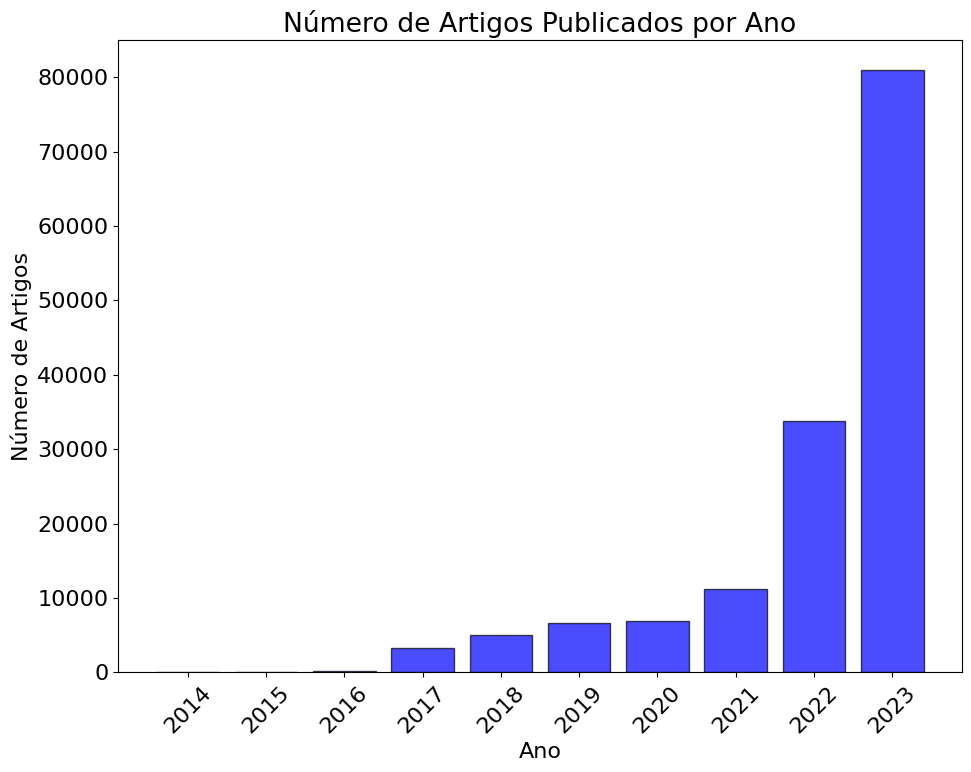

In [ ]:
plt.rcParams.update({'font.size': 16})
plt.figure(figsize=(10, 8))

articles = pd.read_parquet("data/articles/articles_body/articles.parquet")
articles_per_year = articles['publishDate'].dt.year.value_counts().sort_index()
plt.bar(articles_per_year.index, articles_per_year.values, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel('Ano')
plt.xticks(articles_per_year.index, rotation=45)
plt.ylabel('Número de Artigos')
plt.title('Número de Artigos Publicados por Ano')
plt.tight_layout()
plt.savefig("../results/plots/articles_per_year.png")
plt.show()

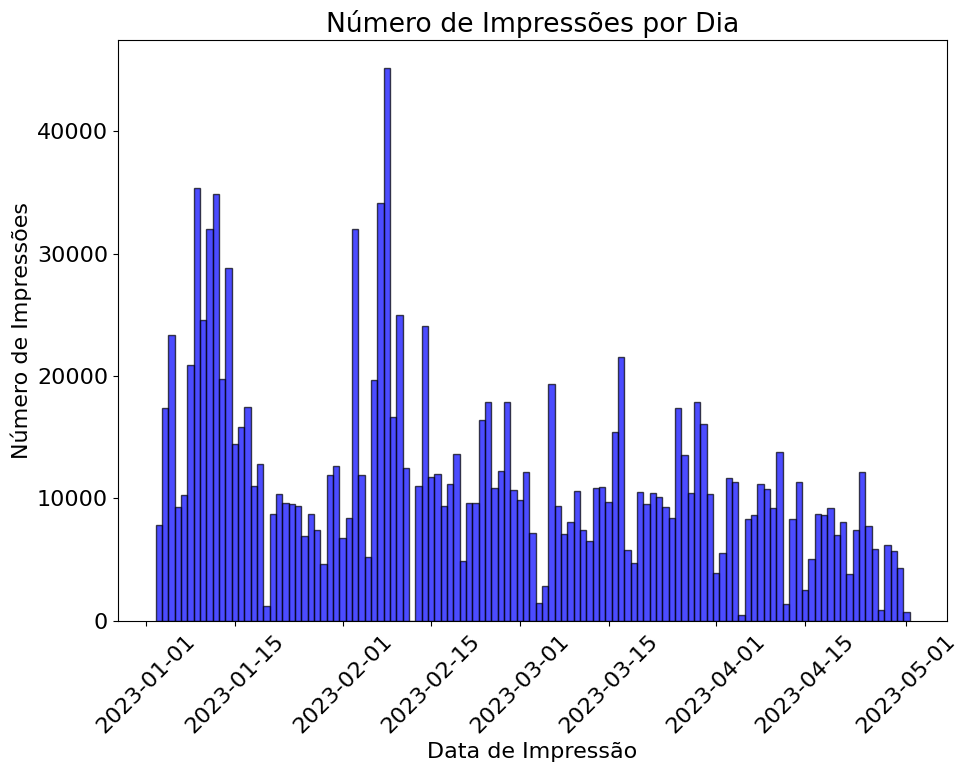

In [ ]:
plt.figure(figsize=(10, 8))
plt.bar(impressions.index.values, impressions.values, width=1.0, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel('Data de Impressão')
plt.xticks(rotation=45)
plt.ylabel('Número de Impressões')
plt.title('Número de Impressões por Dia')
plt.tight_layout()
plt.savefig("results/plots/impressions_per_day.png")
plt.show()

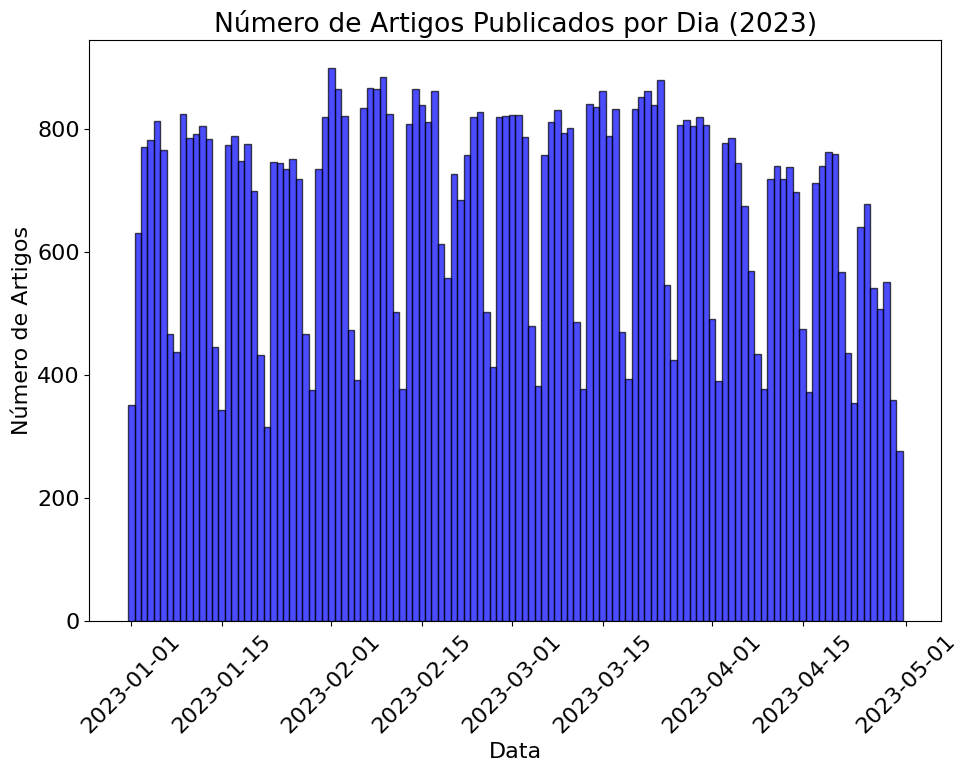

In [ ]:
plt.figure(figsize=(10, 8))
mask = (articles['publishDate'] > '2023-01-01') & (articles['publishDate'] < '2023-05-01')
articles = articles.loc[mask].copy()
articles_per_day = articles['publishDate'].dt.date.value_counts().sort_index()
plt.bar(articles_per_day.index, articles_per_day.values, color='blue', width=1.0, alpha=0.7, edgecolor='black')
plt.xlabel('Data')
plt.xticks(rotation=45)
plt.ylabel('Número de Artigos')
plt.title('Número de Artigos Publicados por Dia (2023)')
plt.tight_layout()
plt.savefig("results/plots/articles_per_day_2023.png")
plt.show()

In [8]:
articles_per_day = articles['publishDate'].dt.date.value_counts().sort_index().agg(['mean', 'median', 'min', 'max', 'std'])
articles_per_day

mean      674.000000
median    748.000000
min       276.000000
max       900.000000
std       176.034708
Name: count, dtype: float64

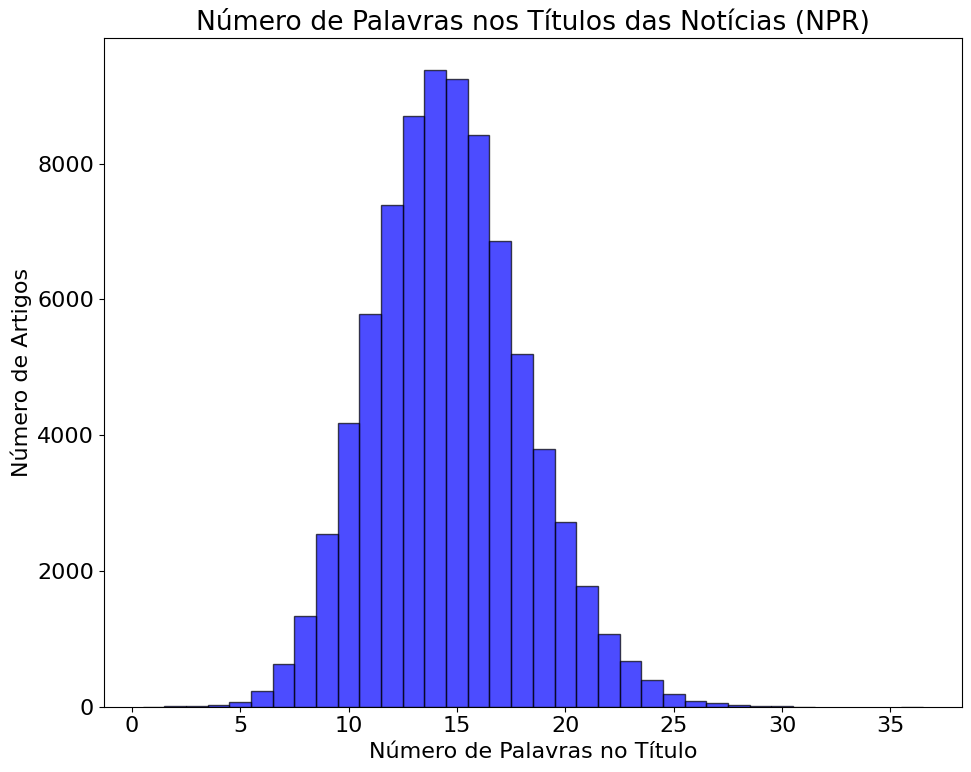

mean      14.650161
median    15.000000
min        1.000000
max       36.000000
std        3.481121
Name: title, dtype: float64

In [ ]:
import re

cleaned_titles = articles["title"].apply(lambda x: re.sub(r"[^\w\s]", "", str(x)))
title_word_counts = cleaned_titles.apply(lambda x: len(x.split()))
articles['title_word_count'] = title_word_counts
articles['title_char_count'] = cleaned_titles.apply(lambda x: len(x))

plt.figure(figsize=(10, 8))
plt.bar(title_word_counts.value_counts().index, title_word_counts.value_counts().values, color='blue', alpha=0.7, edgecolor='black', width=1.0)
plt.xlabel('Número de Palavras no Título')
plt.ylabel('Número de Artigos')
plt.title('Número de Palavras nos Títulos das Notícias (NPR)')
plt.tight_layout()
plt.savefig("results/plots/title_word_counts_npr.png")
plt.show()

stats = title_word_counts.agg(['mean', 'median', 'min', 'max', 'std'])
stats

In [10]:
articles[['title_word_count', 'title_char_count']].describe()

,title_word_count,title_char_count
count,80880.000000,80880.000000
mean,14.650161,86.653548
std,3.481121,19.605918
min,1.000000,5.000000
25%,12.000000,73.000000
50%,15.000000,87.000000
75%,17.000000,99.000000
max,36.000000,193.000000


In [11]:
articles_per_day.describe()

count      5.000000
mean     554.806942
std      313.005793
min      176.034708
25%      276.000000
50%      674.000000
75%      748.000000
max      900.000000
Name: count, dtype: float64

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/gustavoroos/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


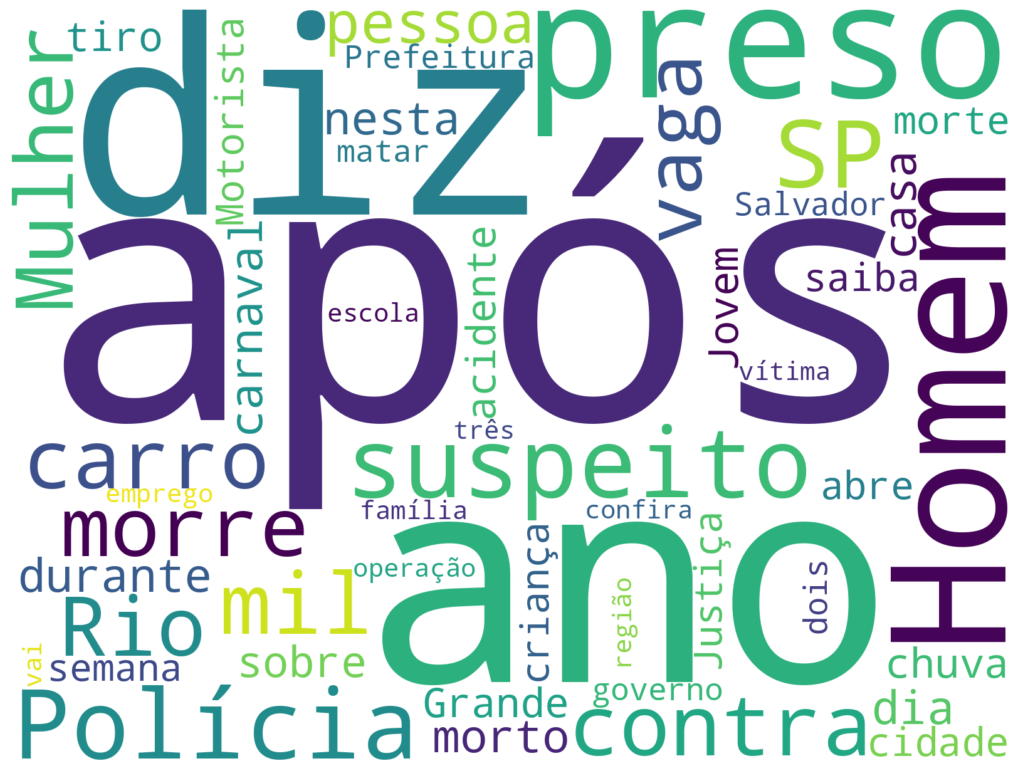

In [12]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import nltk
nltk.download('stopwords')

text = " ".join(cleaned_titles)

stopwords = set(STOPWORDS)
stopwords.update(nltk.corpus.stopwords.words("portuguese") + ["g1", "explica", "veja", "vídeo"])

wordcloud = WordCloud(
    max_words=50,
    background_color="white",
    stopwords=stopwords,
    collocations=False,
    width=1600,
    height=1200,
).generate(text)

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()
# plt.savefig("../results/plots/wordcloud_titles_npr.png")
plt.show()

In [ ]:
articles_ab = pd.read_csv("results/ab/bertopic_v1_topics_globo_2025-06-25_2025-07-26.csv")
articles_ab = articles_ab.drop_duplicates(subset=["documentKey"])
articles_ab['issued'] = pd.to_datetime(articles_ab['issued'])
articles_ab = articles_ab[articles_ab['issued'] > '2025-06-24']
articles_ab.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14060 entries, 0 to 299917
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   documentKey        14060 non-null  object             
 1   doc                14060 non-null  object             
 2   section            14060 non-null  int64              
 3   timestamp          14060 non-null  object             
 4   section_name_list  14060 non-null  object             
 5   issued             14060 non-null  datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](1), int64(1), object(4)
memory usage: 768.9+ KB


In [14]:
articles_per_day_ab = articles_ab['issued'].dt.date.value_counts().sort_index().agg(['mean', 'median', 'min', 'max', 'std'])
articles_per_day_ab

mean      426.060606
median    482.000000
min       113.000000
max       584.000000
std       127.962626
Name: count, dtype: float64

In [15]:
articles_per_day_ab = articles_ab['issued'].dt.date.value_counts().sort_index()
articles_per_day_ab

issued
2025-06-24    113
2025-06-25    405
2025-06-26    485
2025-06-27    474
2025-06-28    308
2025-06-29    262
2025-06-30    502
2025-07-01    584
2025-07-02    572
2025-07-03    581
2025-07-04    489
2025-07-05    311
2025-07-06    237
2025-07-07    486
2025-07-08    564
2025-07-09    482
2025-07-10    439
2025-07-11    428
2025-07-12    272
2025-07-13    233
2025-07-14    402
2025-07-15    532
2025-07-16    517
2025-07-17    532
2025-07-18    456
2025-07-19    273
2025-07-20    250
2025-07-21    514
2025-07-22    538
2025-07-23    492
2025-07-24    551
2025-07-25    517
2025-07-26    259
Name: count, dtype: int64

In [16]:
articles_ab['timestamp'] = pd.to_datetime(articles_ab['timestamp'])
articles_per_run = articles_ab.groupby('timestamp').size().reset_index(name='count')
articles_per_run

,timestamp,count
0,2025-06-25 02:48:04.713750+00:00,10
1,2025-06-25 10:07:07.803424+00:00,46
2,2025-06-25 18:47:48.222753+00:00,147
3,2025-06-26 00:33:16.420418+00:00,16
4,2025-06-26 02:47:23.477068+00:00,5
...,...,...
1257,2025-07-26 22:47:54.891200+00:00,11
1258,2025-07-26 23:04:08.663873+00:00,17
1259,2025-07-26 23:18:06.417879+00:00,23
1260,2025-07-26 23:33:14.806017+00:00,107


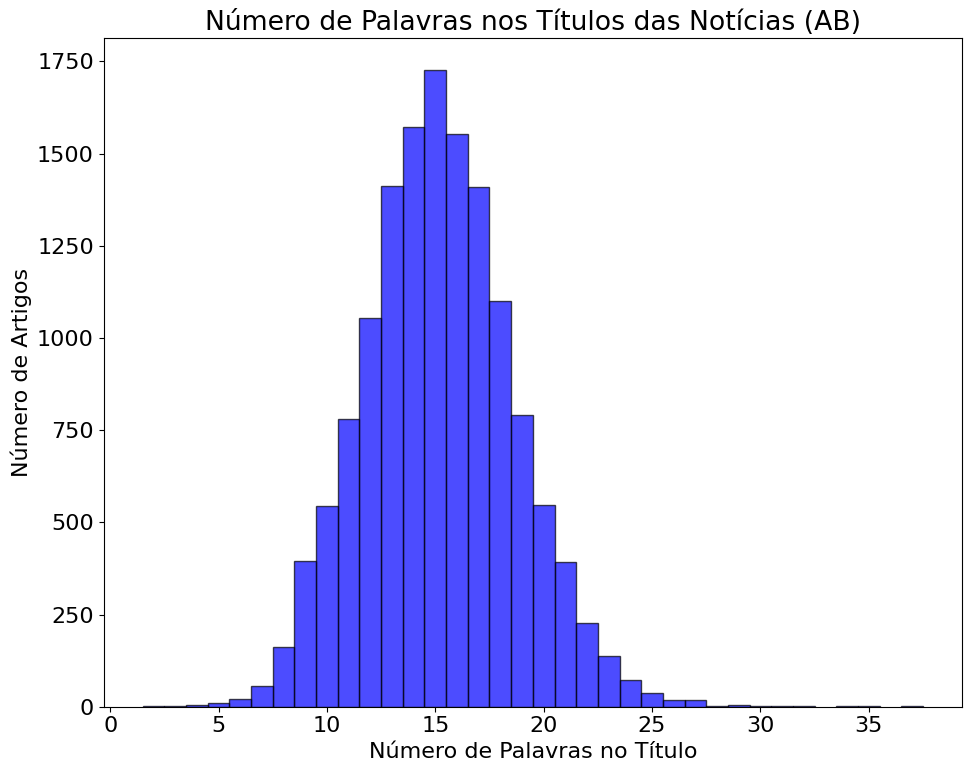

mean      15.186558
median    15.000000
min        2.000000
max       37.000000
std        3.456883
Name: doc, dtype: float64

In [ ]:
import re

cleaned_titles = articles_ab["doc"].apply(lambda x: re.sub(r"[^\w\s]", "", str(x)))
title_word_counts = cleaned_titles.apply(lambda x: len(x.split()))
articles_ab['title_word_count'] = title_word_counts
articles_ab['title_char_count'] = cleaned_titles.apply(lambda x: len(x))

plt.figure(figsize=(10, 8))
plt.bar(title_word_counts.value_counts().index, title_word_counts.value_counts().values, color='blue', alpha=0.7, edgecolor='black', width=1.0)
plt.xlabel('Número de Palavras no Título')
plt.ylabel('Número de Artigos')
plt.title('Número de Palavras nos Títulos das Notícias (AB)')
plt.tight_layout()
plt.savefig("results/plots/title_word_counts_ab.png")
plt.show()

stats = title_word_counts.agg(['mean', 'median', 'min', 'max', 'std'])
stats

In [18]:
articles_ab[['title_word_count', 'title_char_count']].describe()

,title_word_count,title_char_count
count,14060.000000,14060.000000
mean,15.186558,89.445164
std,3.456883,19.198212
min,2.000000,15.000000
25%,13.000000,77.000000
50%,15.000000,89.000000
75%,17.000000,102.000000
max,37.000000,210.000000


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/gustavoroos/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


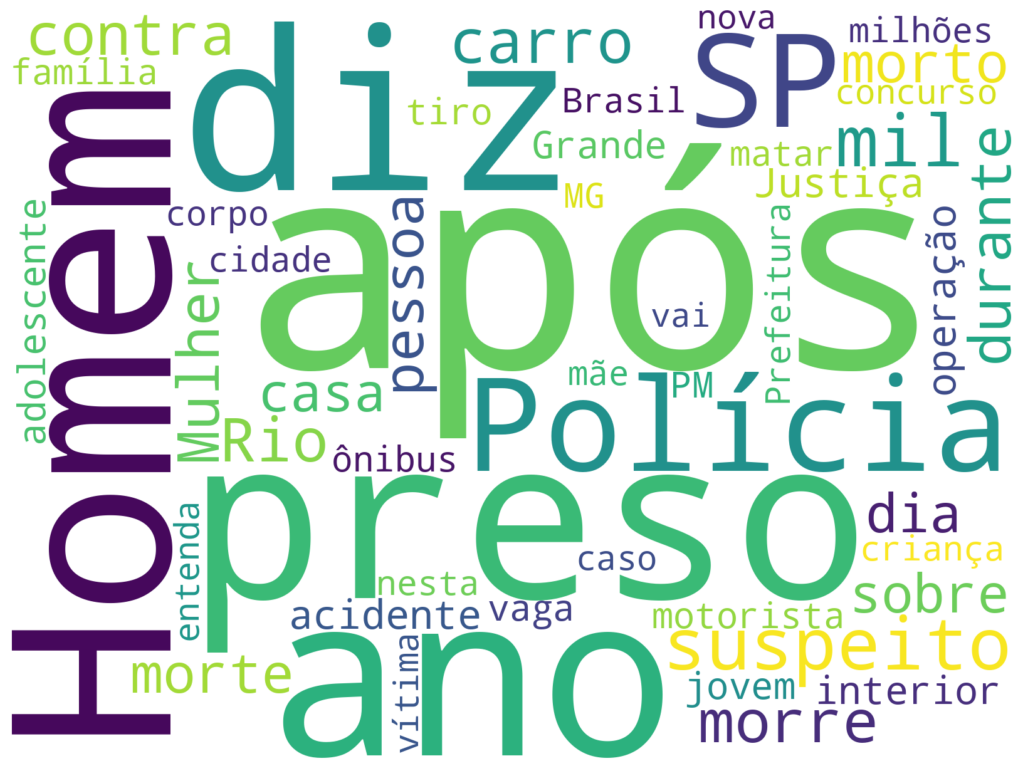

In [ ]:
nltk.download('stopwords')

text = " ".join(cleaned_titles)

stopwords = set(STOPWORDS)
stopwords.update(nltk.corpus.stopwords.words("portuguese") + ["g1", "explica", "veja", "vídeo"])

wordcloud = WordCloud(
    max_words=50,
    background_color="white",
    stopwords=stopwords,
    collocations=False,
    width=1600,
    height=1200,
).generate(text)

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()
plt.savefig("results/plots/wordcloud_titles_ab.png")
plt.show()